## Music Recommender System
#### Content-Based Recommendation using Audio Features and Artist Information

![Python](https://img.shields.io/badge/Python-3.10-blue?logo=python&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-ML-orange?logo=scikitlearn&logoColor=white)
![Pandas](https://img.shields.io/badge/Pandas-Data-150458?logo=pandas&logoColor=white)
![Status](https://img.shields.io/badge/Status-Complete-brightgreen)

In this project, we build a music recommendation system that suggests similar tracks based on audio characteristics and artist information. This is a **Content-Based Filtering** approach: similarity between songs is determined by their intrinsic features, not by user interaction history.

### Project Objectives
- Explore and understand the dataset before modeling (distributions, correlations, outliers).
- Engineer features: convert categorical (artists) and numeric (audio) data into a model-ready format.
- Compare **two similarity strategies**: Nearest Neighbors with **Cosine distance** (on the full feature set) and Nearest Neighbors with **Jaccard distance** (on the binary artist-overlap signal).
- Visualize data patterns and recommendation results.
- Summarize findings and trade-offs in a final conclusion.


## 1. Imports

In [99]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors

sns.set_style("whitegrid")

## 2. Load the Data

In [100]:
df_origin = pd.read_csv('tracks_features.csv')
print("Raw shape:", df_origin.shape)
df_origin.head(3)

Raw shape: (1204025, 24)


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.0261,0.000011,0.356,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.0129,0.000071,0.155,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.0234,0.000002,0.122,0.370,149.749,298893,4.0,1999,1999-11-02


In [101]:
df_origin.info()      # memory usage  ------------->  212.4 MB

<class 'pandas.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1204025 non-null  str    
 1   name              1204022 non-null  str    
 2   album             1204014 non-null  str    
 3   album_id          1204025 non-null  str    
 4   artists           1204025 non-null  str    
 5   artist_ids        1204025 non-null  str    
 6   track_number      1204025 non-null  int64  
 7   disc_number       1204025 non-null  int64  
 8   explicit          1204025 non-null  bool   
 9   danceability      1204025 non-null  float64
 10  energy            1204025 non-null  float64
 11  key               1204025 non-null  int64  
 12  loudness          1204025 non-null  float64
 13  mode              1204025 non-null  int64  
 14  speechiness       1204025 non-null  float64
 15  acousticness      1204025 non-null  float64
 16  instrumenta

In [103]:
# Keep only the columns relevant to content-based similarity

#df_origin.drop(columns=['id','album_id','artist_ids','disc_number','track_number','key'],inplace=True)
df = df_origin[['name', 'artists', 'danceability', 'energy', 'loudness',
                 'speechiness', 'acousticness', 'valence', 'tempo',
                 'duration_ms', 'year']].copy()

print("Working shape:", df.shape)
df.head(3)

Working shape: (1204025, 11)


,name,artists,danceability,energy,loudness,speechiness,acousticness,valence,tempo,duration_ms,year
0,Testify,['Rage Against The Machine'],0.470,0.978,-5.399,0.0727,0.0261,0.503,117.906,210133,1999
1,Guerrilla Radio,['Rage Against The Machine'],0.599,0.957,-5.764,0.1880,0.0129,0.489,103.680,206200,1999
2,Calm Like a Bomb,['Rage Against The Machine'],0.315,0.970,-5.424,0.4830,0.0234,0.370,149.749,298893,1999


## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand what we are working with: are there missing values, what do the numeric distributions look like, are there outliers, and are any features redundant with each other?

**check nulls data**

In [104]:
df.info()    # memory usage  ------------->  101.0 MB

<class 'pandas.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 11 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   name          1204022 non-null  str    
 1   artists       1204025 non-null  str    
 2   danceability  1204025 non-null  float64
 3   energy        1204025 non-null  float64
 4   loudness      1204025 non-null  float64
 5   speechiness   1204025 non-null  float64
 6   acousticness  1204025 non-null  float64
 7   valence       1204025 non-null  float64
 8   tempo         1204025 non-null  float64
 9   duration_ms   1204025 non-null  int64  
 10  year          1204025 non-null  int64  
dtypes: float64(7), int64(2), str(2)
memory usage: 101.0 MB


In [105]:
# Missing value count per column
missing_counts = df.isnull().sum()
missing_counts[missing_counts > 0]

name    3
dtype: int64

In [106]:
# Drop rows with a missing song name (the key we use for lookups later)
df.dropna(subset=['name'], inplace=True)
df.reset_index(drop=True, inplace=True)
print("Shape after dropping missing names:", df.shape)

Shape after dropping missing names: (1204022, 11)


**check size of each column**

In [107]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

274.1581621170044 MB


In [108]:
#-------------------int-----------------
df["year"] = df["year"].astype("uint16")
df["duration_ms"] = df["duration_ms"].astype("uint32")
#---------------------float------------
float_cols = df.select_dtypes(include=["float64"]).columns

for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast="float")

In [110]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

230.52485752105713 MB


In [111]:
df.info()      #memory usage: 57.3 MB

<class 'pandas.DataFrame'>
RangeIndex: 1204022 entries, 0 to 1204021
Data columns (total 11 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   name          1204022 non-null  str    
 1   artists       1204022 non-null  str    
 2   danceability  1204022 non-null  float32
 3   energy        1204022 non-null  float32
 4   loudness      1204022 non-null  float32
 5   speechiness   1204022 non-null  float32
 6   acousticness  1204022 non-null  float32
 7   valence       1204022 non-null  float32
 8   tempo         1204022 non-null  float32
 9   duration_ms   1204022 non-null  uint32 
 10  year          1204022 non-null  uint16 
dtypes: float32(7), str(2), uint16(1), uint32(1)
memory usage: 57.4 MB


**check value of each column**

In [112]:
print(df['danceability'].value_counts())

danceability
0.0000    2778
0.5330    2496
0.5290    2490
0.5340    2460
0.5070    2443
          ... 
0.0577       1
0.0343       1
0.0380       1
0.9930       1
0.0529       1
Name: count, Length: 1362, dtype: int64


In [113]:
print(df['tempo'].value_counts())

tempo
0.000000      2777
120.000999     305
119.999001     287
120.002998     287
120.001999     282
              ... 
179.397995       1
159.207001       1
65.851997        1
179.138000       1
191.910995       1
Name: count, Length: 140472, dtype: int64


In [114]:
print(df['year'].value_counts())

year
2020    69725
2019    67276
2006    56945
2007    56287
2018    56167
        ...  
1920       25
1935       20
1908       19
1900       14
0          10
Name: count, Length: 101, dtype: int64


In [115]:
df = df[df['danceability'] != 0.0000]
df = df[df['tempo'] != 0.000000]
df = df[df['year'] != 0]

### 3.1 Descriptive Statistics of Numeric Columns

In [118]:
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                 'acousticness', 'valence', 'tempo', 'duration_ms', 'year']

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
danceability,1201234.0,0.494194,0.188398,0.006350,0.3570,0.501000,0.633000,1.000000e+00
energy,1201234.0,0.510047,0.294477,0.000000,0.2530,0.524000,0.767000,1.000000e+00
loudness,1201234.0,-11.784737,6.934833,-58.924999,-15.2230,-9.779000,-6.713000,7.234000e+00
speechiness,1201234.0,0.084577,0.116055,0.000000,0.0352,0.044600,0.072400,9.690000e-01
acousticness,1201234.0,0.446545,0.385136,0.000000,0.0376,0.388000,0.861000,9.960000e-01
valence,1201234.0,0.428974,0.270012,0.000000,0.1930,0.404000,0.645000,1.000000e+00
tempo,1201234.0,117.906349,30.450806,30.018000,94.2220,116.872002,137.108002,2.489340e+02
duration_ms,1201234.0,249313.118223,161909.901270,15000.000000,174499.0000,224538.500000,286000.000000,6.061090e+06
year,1201234.0,2007.347709,10.629012,1900.000000,2002.0000,2009.000000,2015.000000,2.020000e+03


Observations from the summary statistics:
- `danceability`, `energy`, `acousticness`, `valence` are already bounded roughly in [0, 1] — as expected for Spotify's normalized audio features.
- `loudness` is negative (measured in decibels relative to a reference level), so it needs the same [0, 1] rescaling as everything else before it can be compared to other features.
- `tempo` and `duration_ms` are on completely different numeric scales (tens to hundreds vs. hundreds of thousands) — a strong signal that scaling is required before combining features.
- `speechiness` has a very tight distribution close to 0 for most tracks, which we verify visually below.

### 3.2 Distribution of Each Numeric Feature

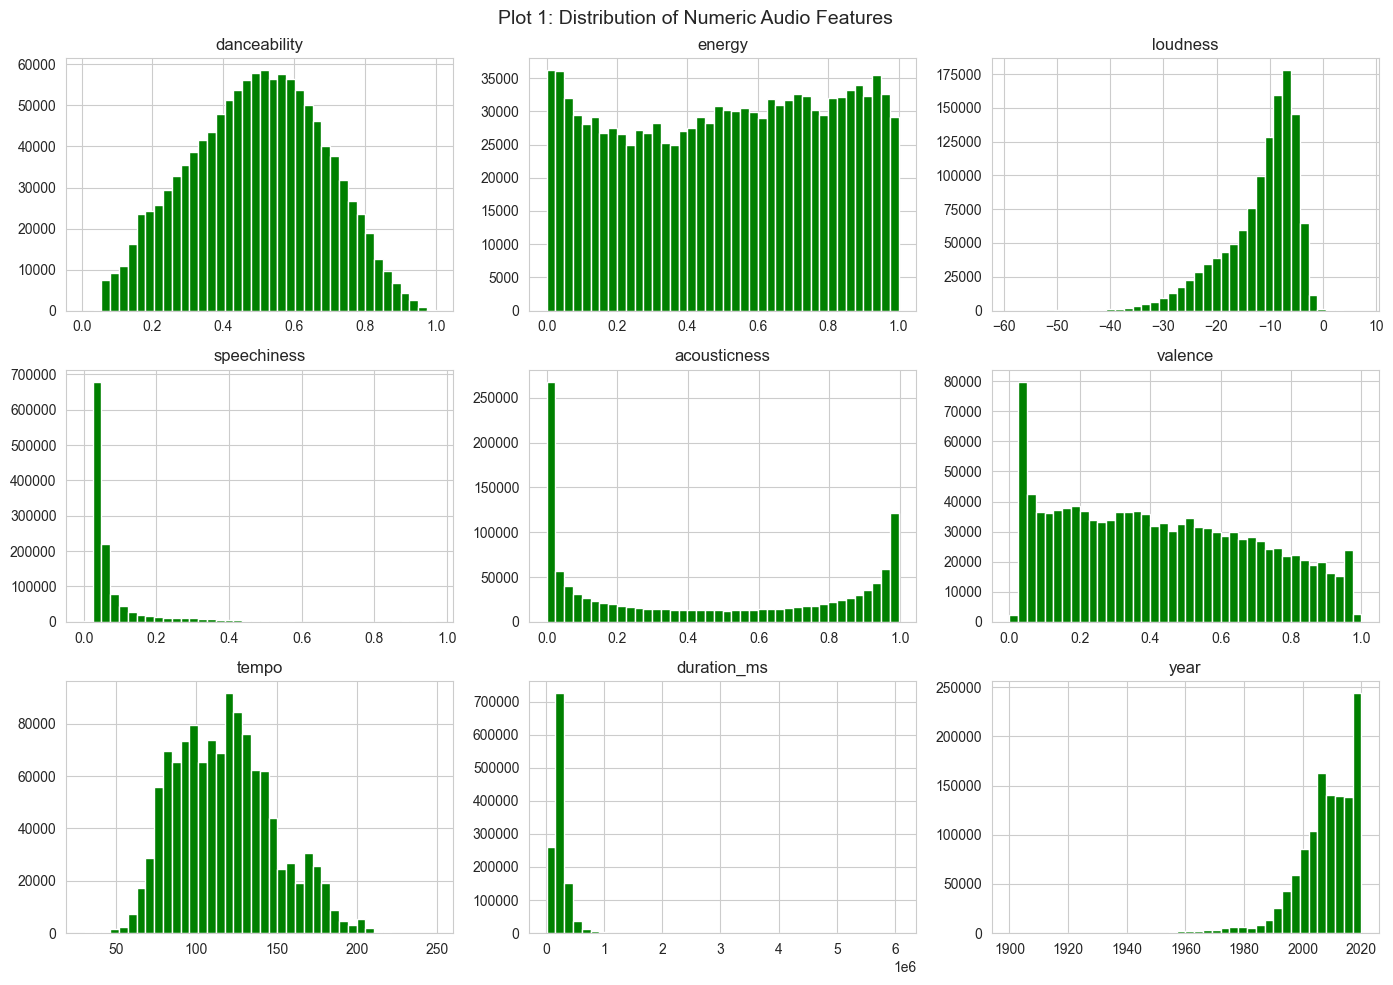

In [119]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='green')
    axes[i].set_title(col)

plt.suptitle('Plot 1: Distribution of Numeric Audio Features', fontsize=14)
plt.tight_layout()
plt.show()


`speechiness` and `acousticness` are heavily right-skewed (most tracks have low values, with a long tail of high-value outliers), while `danceability`, `energy`, and `valence` are closer to a normal/uniform spread. `duration_ms` also has a long right tail — a small number of unusually long tracks.

### 3.3 Correlation Between Numeric Features

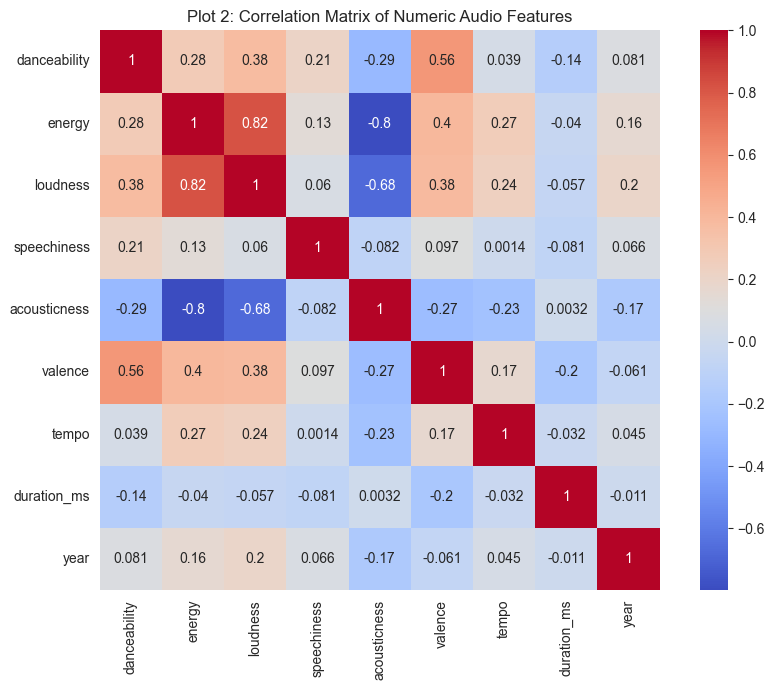

In [120]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Plot 2: Correlation Matrix of Numeric Audio Features')
plt.tight_layout()
plt.show()


**Feature decision based on correlation:** `energy` and `loudness` show a fairly strong positive correlation (louder tracks tend to be more energetic), which is expected physically. The correlation is not extreme enough to call the two features redundant, so **both are kept** — dropping one would throw away information that isn't fully captured by the other (e.g. an acoustic-but-loud outlier vs. a quiet-but-energetic outlier). No feature is dropped purely on the basis of this correlation check.

### 3.4 Comparing Pairs of Features Directly

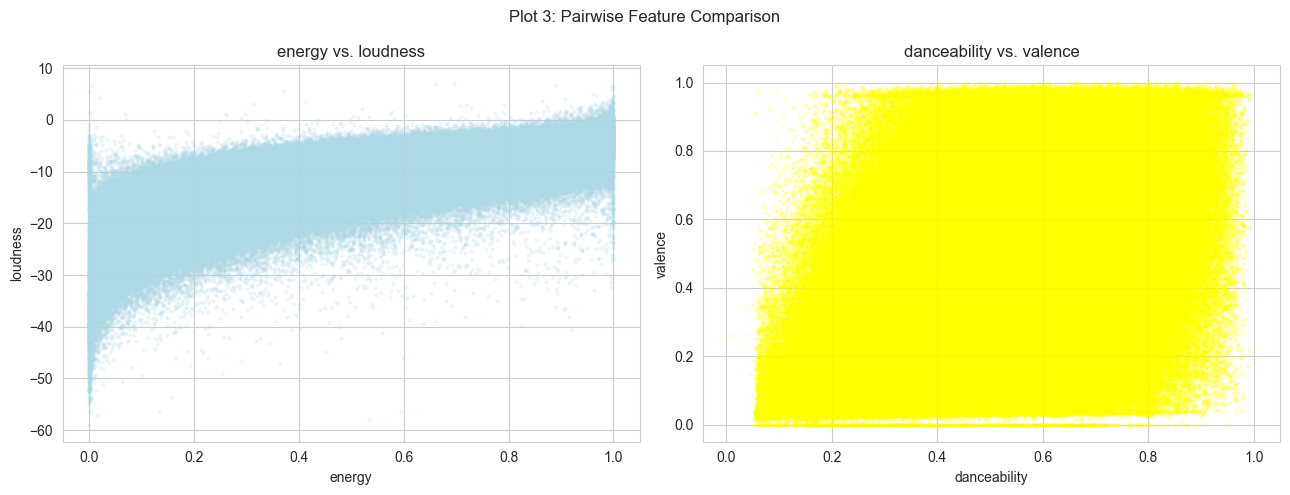

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['energy'], df['loudness'], s=4, alpha=0.15, color='lightblue')
axes[0].set_xlabel('energy')
axes[0].set_ylabel('loudness')
axes[0].set_title('energy vs. loudness')

axes[1].scatter(df['danceability'], df['valence'], s=4, alpha=0.15, color='yellow')
axes[1].set_xlabel('danceability')
axes[1].set_ylabel('valence')
axes[1].set_title('danceability vs. valence')

plt.suptitle('Plot 3: Pairwise Feature Comparison')
plt.tight_layout()
plt.show()

### 3.5 Tracks Over Time

In [122]:
tracks_per_year = df['year'].value_counts().sort_index()
tracks_per_year

year
1900       14
1908       19
1909       25
1917       52
1920       25
        ...  
2016    47349
2017    51236
2018    56088
2019    67168
2020    69566
Name: count, Length: 100, dtype: int64

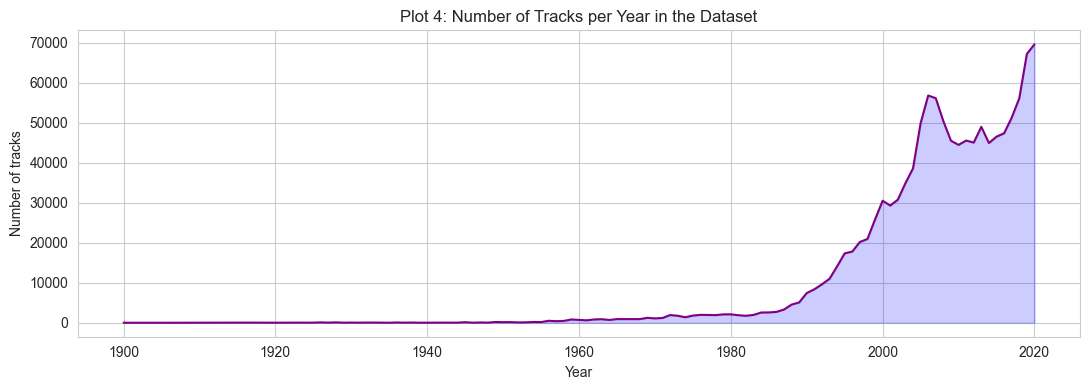

In [123]:
plt.figure(figsize=(11, 4))
plt.plot(tracks_per_year.index, tracks_per_year.values, color='purple')
plt.fill_between(tracks_per_year.index, tracks_per_year.values, alpha=0.2, color='blue')
plt.xlabel('Year')
plt.ylabel('Number of tracks')
plt.title('Plot 4: Number of Tracks per Year in the Dataset')
plt.tight_layout()
plt.show()

The dataset is heavily weighted toward recent decades, which is expected for a streaming-era catalog. This is useful context: recommendations for older tracks are drawn from a much smaller pool than recommendations for recent tracks.

### 3.6 Outlier Handling — `duration_ms`

The histogram above showed a long right tail for `duration_ms` (a handful of tracks that are unusually long — interludes, spoken-word tracks, or data errors). Extremely long outliers can distort `MinMaxScaler`, since the scaler's [0, 1] range is anchored to the min and max values: a single extreme outlier compresses every normal track into a tiny sub-range near 0.

In [124]:
q1 = df['duration_ms'].quantile(0.25)
q3 = df['duration_ms'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 3 * iqr  # a wide 3xIQR bound, so we only cap extreme outliers, not normal long songs

outlier_count = (df['duration_ms'] > upper_bound).sum()
print(f"Tracks beyond the upper bound ({upper_bound:.0f} ms): {outlier_count} "
      f"({outlier_count / len(df) * 100:.3f}% of the dataset)")

# Cap (do not drop) extreme outliers, so we keep the tracks but stop them from
# dominating the scaled range
df['duration_ms'] = df['duration_ms'].clip(upper=upper_bound)


Tracks beyond the upper bound (620503 ms): 25115 (2.091% of the dataset)


**Feature decision:** outliers are **capped, not dropped**. Dropping rows would lose otherwise valid tracks (and their artist information); capping keeps every track in the dataset while preventing a handful of extreme values from compressing the scaled range for everyone else.

### 3.7 Feature Engineering — Adding a `decade` Column

`year` alone is a very high-cardinality numeric feature (potentially one unique value per year across many decades). For exploratory purposes, grouping tracks into decades gives a clearer, coarser view of how audio characteristics have shifted over time. This column is used for visualization only — the model itself still uses the finer-grained scaled `year` feature.

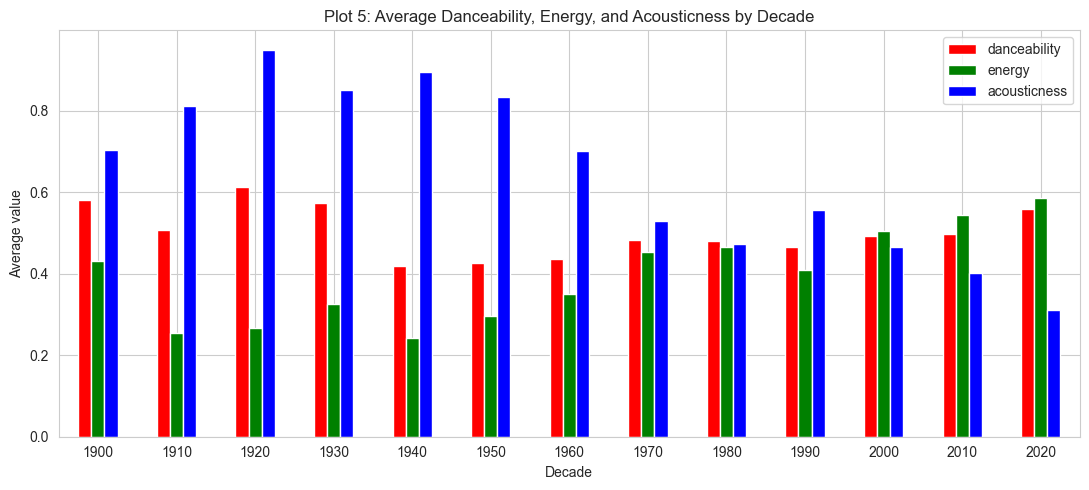

In [126]:
df['decade'] = (df['year'] // 10 * 10).astype(int)

decade_means = df.groupby('decade')[['danceability', 'energy', 'acousticness']].mean()

decade_means.plot(kind='bar', figsize=(11, 5), color=['r', 'g', 'b'])
plt.title('Plot 5: Average Danceability, Energy, and Acousticness by Decade')
plt.ylabel('Average value')
plt.xlabel('Decade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A visible trend: average `acousticness` declines in more recent decades while `energy` and `danceability` trend upward — consistent with the shift toward more heavily produced, higher-energy music in modern catalogs.

## 4. Text Feature Engineering — Cleaning Artist Names

In [127]:
def clean_artist_names(artist_str):
    names = re.findall(r"'([^']+)'", artist_str)
    cleaned_names = [name.replace(' ', '_') for name in names]
    return ' '.join(cleaned_names)

df['Artists_Clean'] = df['artists'].apply(clean_artist_names)
df[['name', 'artists', 'Artists_Clean']].head(5)

,name,artists,Artists_Clean
0,Testify,['Rage Against The Machine'],Rage_Against_The_Machine
1,Guerrilla Radio,['Rage Against The Machine'],Rage_Against_The_Machine
2,Calm Like a Bomb,['Rage Against The Machine'],Rage_Against_The_Machine
3,Mic Check,['Rage Against The Machine'],Rage_Against_The_Machine
4,Sleep Now In the Fire,['Rage Against The Machine'],Rage_Against_The_Machine


## 5. Vectorization and Scaling

In [128]:
vect = CountVectorizer()
artist_matrix = vect.fit_transform(df['Artists_Clean'])   # sparse matrix, kept sparse on purpose
print("Artist matrix shape:", artist_matrix.shape)

Artist matrix shape: (1201234, 138558)


In [129]:
scaler = MinMaxScaler()
numeric_scaled = scaler.fit_transform(df[numeric_cols])
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=numeric_cols)
numeric_scaled_df.head(3)


,danceability,energy,loudness,speechiness,acousticness,valence,tempo,duration_ms,year
0,0.466613,0.978,0.809051,0.075026,0.026205,0.503,0.401469,0.322266,0.825
1,0.596437,0.957,0.803534,0.194014,0.012952,0.489,0.336485,0.315771,0.825
2,0.310622,0.970,0.808673,0.498452,0.023494,0.370,0.546927,0.468855,0.825


In [200]:
numeric_scaled_weighted = numeric_scaled * 10
final_matrix = hstack([artist_matrix, numeric_scaled_weighted]).tocsr()
final_matrix.shape

(1201234, 138567)

## 6. Model 1 — Nearest Neighbors with Cosine Distance

`cosine` distance is well suited to the **combined** feature matrix, since it measures the angle between vectors rather than raw magnitude — appropriate here because the matrix mixes sparse count-based artist columns with scaled continuous audio features.

In [201]:
cosine_model = NearestNeighbors(
    metric='cosine',
    n_neighbors = 5,
    radius = 1.3,
    algorithm = "auto",
    leaf_size= 40
)
cosine_model.fit(final_matrix)

,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.3
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",40
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


## 6. Model 2 — Nearest Neighbors with Cosine Distance

In [202]:
euclidean_model = NearestNeighbors(
    n_neighbors=5,
    metric='euclidean',
    algorithm='brute',
)
euclidean_model.fit(final_matrix)

,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


## 8. Recommendation Functions

In [204]:
def get_track_index(song_name):
    matches = np.where(df['name'] == song_name)[0]
    if len(matches) == 0:
        print(f"'{song_name}' was not found in the dataset.")
        return None
    return matches[0]


def recommend_cosine(song_name, n=5):
    idx = get_track_index(song_name)
    if idx is None:
        return None
    distances, indices = cosine_model.kneighbors(final_matrix[idx], n_neighbors=n + 1)
    recommended_idx = indices[0][1:]
    recommended_dist = distances[0][1:]
    return list(zip(df['name'].iloc[recommended_idx], recommended_dist))


def recommend_euclidean(song_name, n=5):
    idx = get_track_index(song_name)
    if idx is None:
        return None
    distances, indices = euclidean_model.kneighbors(final_matrix[idx], n_neighbors=n + 1)
    recommended_idx = indices[0][1:]
    recommended_dist = distances[0][1:]
    return list(zip(df['name'].iloc[recommended_idx], recommended_dist))


## 9. Try It Out

In [205]:
user_song = input("Enter Song Name: ")

cosine_results = recommend_cosine(user_song)
euclidean_result = recommend_euclidean(user_song)

if cosine_results is not None:
    print("\nCosine (audio + artist) recommendations:")
    for title, dist in cosine_results:
        print(f"  - {title}  (distance: {dist:.3f})")

if euclidean_result is not None:
    print("\neuclidean_model (audio + artist) recommendations:")
    for title, dist in euclidean_result:
        print(f"  - {title}  (distance: {dist:.3f})")



Cosine (audio + artist) recommendations:
  - Freedom  (distance: 0.001)
  - Township Rebellion  (distance: 0.004)
  - The Man From Hell  (distance: 0.005)
  - 21st Century Love  (distance: 0.005)
  - Factory  (distance: 0.005)

euclidean_model (audio + artist) recommendations:
  - Freedom  (distance: 0.852)
  - Township Rebellion  (distance: 1.398)
  - Soldier's Blues  (distance: 1.709)
  - Catatonic  (distance: 1.725)
  - The Beast Inside  (distance: 1.727)


## 10. Visualizing the Two Recommendation Sets

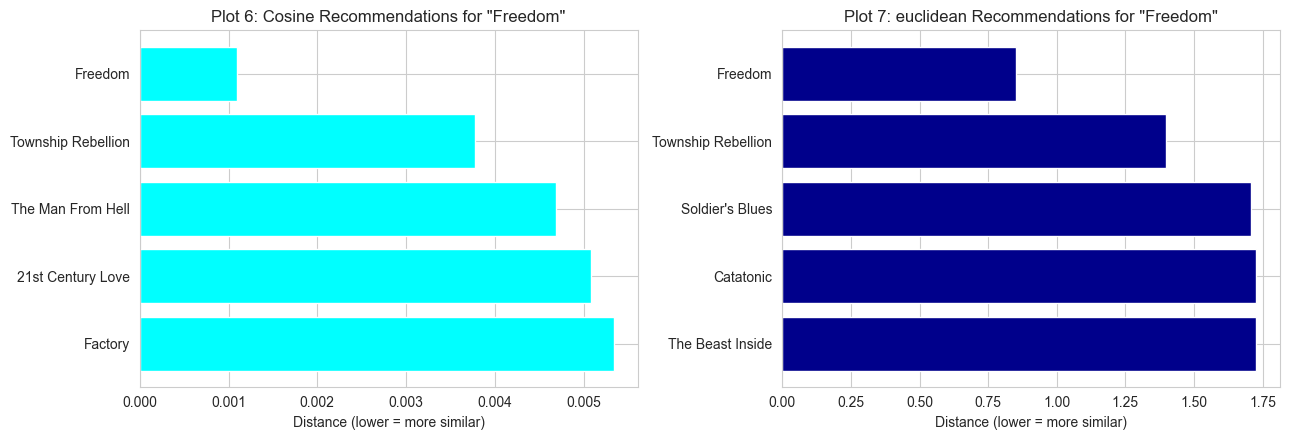

In [206]:
if cosine_results is not None and euclidean_result is not None:
    cosine_titles = [t for t, d in cosine_results][::-1]
    cosine_dists = [d for t, d in cosine_results][::-1]

    euclidean_titles = [t for t, d in euclidean_result][::-1]
    euclidean_dists = [d for t, d in euclidean_result][::-1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].barh(cosine_titles, cosine_dists, color='aqua')
    axes[0].set_xlabel('Distance (lower = more similar)')
    axes[0].set_title(f'Plot 6: Cosine Recommendations for "{user_song}"')

    axes[1].barh(euclidean_titles, euclidean_dists, color='darkblue')
    axes[1].set_xlabel('Distance (lower = more similar)')
    axes[1].set_title(f'Plot 7: euclidean Recommendations for "{user_song}"')

    plt.tight_layout()
    plt.show()


## 11. Conclusion

**Why two different Nearest Neighbors models:**
I just decided to see different results by give weight to another model:

Weighting the audio features was necessary because, in raw form, the thousands of sparse artist dimensions completely overpowered the 9 numeric audio features in the distance calculation — after weighting, the model started recommending based on actual sound similarity, not just shared artist

**Limitations and possible next steps:**
- Genre or additional metadata (if available in the source data) could add another content signal beyond audio features and artist identity.
- For production-scale use, an approximate nearest neighbor index (e.g. FAISS or Annoy) would scale better than scikit-learn's brute-force search as the catalog grows further.
